Project Summary and Research Questions

This project examines how plant-based food markets and YouTube narratives developed across selected European countries from 2018 to 2020. It combines country-year-product sales data with YouTube video text data to compare market size, product-category composition, narrative prevalence, and the relationship between online narratives and plant-based food sales. Since sales value and volume are strongly correlated, the later analysis focuses mainly on Value EUR as the key market indicator. The YouTube analysis uses fourteen aspect-sentiment narrative variables: health, environment, animal welfare, food security, taste, price, and convenience, each split into positive and negative mentions.

- Main RQ: How are YouTube narratives about plant-based foods associated with plant-based food sales patterns across selected European countries from 2018 to 2020?
- Sub-RQ1: How do plant-based food sales values vary across countries, years, and product groups?
- Sub-RQ2: How does the product-category composition of plant-based food sales differ across countries and over time?
- Sub-RQ3: Which positive and negative YouTube narratives are most frequently mentioned across countries and years?
- Sub-RQ4: To what extent are the fourteen YouTube narrative categories associated with total plant-based food sales value at the country-year level?


In [33]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from analysis_helpers import (
    add_sales_log_columns,
    create_share_table,
    create_wide_value_table,
    fit_ols,
    prepare_sales_data,
    print_basic_info,
    print_sales_overview,
)
print(f"current working directory:{os.getcwd()}")
print("Files in current directory:")
print(os.listdir("."))


current working directory:e:\东京大学\Video-Analysis--DataScience-Group\notebooks
Files in current directory:
['0610 Group I.ipynb', '0610 Group I.py']


In [34]:
df = pd.read_csv("../data/Clean/plant_based_food_sales_data.csv")
print_basic_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product Group              3545 non-null   object 
 1   Product Group Detail       3545 non-null   object 
 2   Aggregation Level          3545 non-null   object 
 3   Cleaning Basis             3545 non-null   object 
 4   Original Product Group     3545 non-null   object 
 5   Source File                3545 non-null   object 
 6   Source Sheet               3545 non-null   object 
 7   Country                    3545 non-null   object 
 8   Market                     3545 non-null   object 
 9   Retail Channel             3545 non-null   object 
 10  Product Category           3539 non-null   object 
 11  Product Segment            3468 non-null   object 
 12  Product Subsegment         0 non-null      float64
 13  Product Type               2649 non-null   objec

In [35]:
df = prepare_sales_data(df)

In [36]:
print_sales_overview(df)

Head
   Country    Year                                     Product Group  \
0  Austria  2018.0  Plant-based meat/fish alternatives & ready meals   
1  Austria  2018.0                         Plant-based milk & drinks   

    Value EUR  Volume kg/l  
0  47756571.0    4539225.6  
1  60439596.8   30683478.8  
Tail
           Country    Year              Product Group     Value EUR  \
98  United Kingdom  2020.0  Plant-based milk & drinks  4.523603e+08   
99  United Kingdom  2020.0         Plant-based yogurt  3.031181e+07   

    Volume kg/l  
98  291010516.4  
99    6468243.4  

Unique countries in the dataset:
['Austria' 'Belgium' 'Denmark' 'France' 'Italy' 'Netherlands' 'Romania'
 'Spain' 'United Kingdom']

Unique years in the dataset:
[2018. 2019. 2020.]

Unique product groups in the dataset:
['Plant-based meat/fish alternatives & ready meals'
 'Plant-based milk & drinks' 'Plant-based yogurt' 'Plant-based cheese'
 'Plant-based ice cream' 'Other plant-based foods / snacks & spreads']


array([[<Axes: title={'center': 'Value EUR'}>,
        <Axes: title={'center': 'Volume kg/l'}>]], dtype=object)

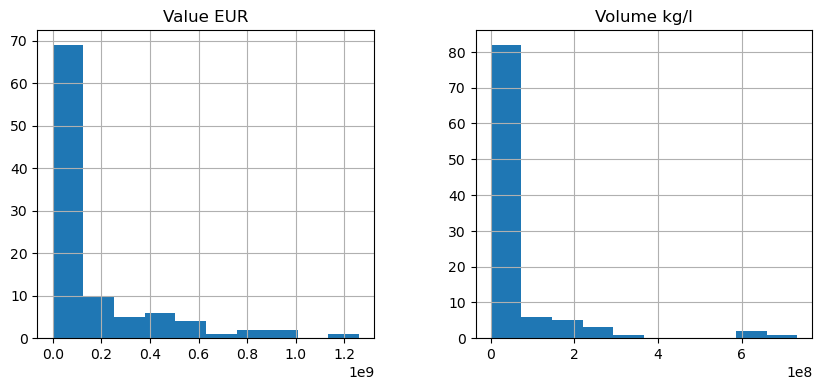

In [37]:
df[['Value EUR', 'Volume kg/l']].hist(figsize=(10, 4))

The histograms show that both sales value and sales volume are strongly right-skewed, with most observations concentrated at lower levels and only a small number of observations showing very large values. This indicates substantial variation across countries, years, and product categories. Since the dataset contains both value and volume information, the subsequent analysis examines whether higher sales volumes are associated with higher sales values, which would suggest a broadly positive value–volume relationship. Applying log transformation helps reduce the influence of extreme observations and makes the variables more suitable for regression analysis when testing this relationship.


array([[<Axes: title={'center': 'log_value'}>,
        <Axes: title={'center': 'log_volume'}>]], dtype=object)

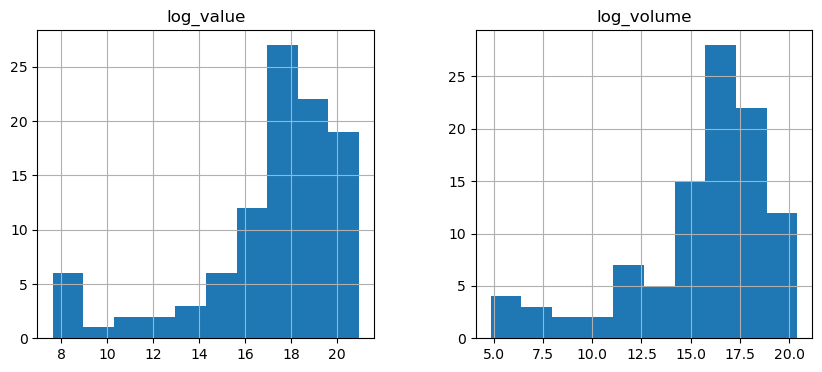

In [38]:
import numpy as np
df = add_sales_log_columns(df)
df[['log_value', 'log_volume']].hist(figsize=(10, 4))

After log transformation, the distributions of log_value and log_volume become less right-skewed compared with the original variables. The values are more spread out and less dominated by extreme observations, making them more suitable for correlation and OLS regression analysis.


In [39]:
import statsmodels.api as sm
X = sm.add_constant(df[['log_volume']])
model_log = fit_ols(df, ['log_volume'], 'log_value')
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_value   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     2176.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.01e-68
Time:                        10:46:34   Log-Likelihood:                -98.560
No. Observations:                 100   AIC:                             201.1
Df Residuals:                      98   BIC:                             206.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8911      0.290     13.424      0.0

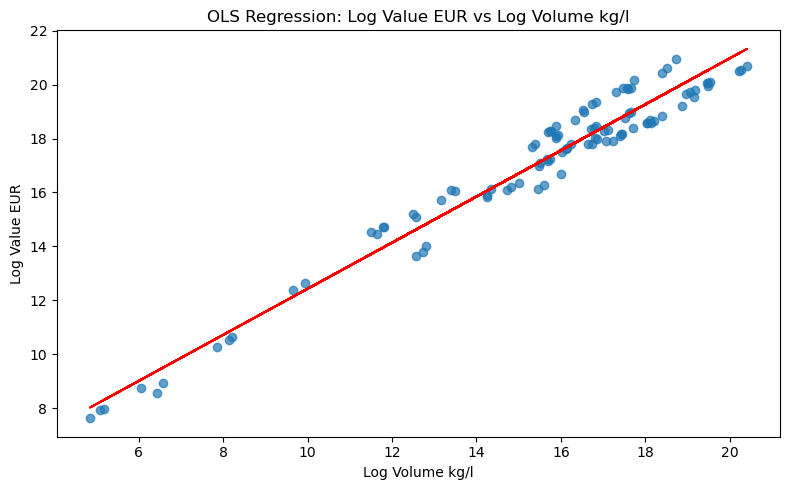

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(df['log_volume'], df['log_value'], alpha=0.7)
plt.plot(df['log_volume'], model_log.predict(X),color='red')
plt.title('OLS Regression: Log Value EUR vs Log Volume kg/l')
plt.xlabel('Log Volume kg/l')
plt.ylabel('Log Value EUR')
plt.tight_layout()
plt.show()

The log-log OLS regression shows a strong positive relationship between Volume kg/l and Value EUR. The model has a high R-squared value of 0.957, indicating that log volume explains most of the variation in log sales value. The coefficient of log_volume is positive and statistically significant, suggesting that higher sales volume is strongly associated with higher sales value. Therefore, since value and volume are highly correlated, the following analysis focuses on Value EUR as the main indicator and does not discuss Volume kg/l separately.


In [41]:
df_wide_value = create_wide_value_table(df)
df_wide_value.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt,Total Value EUR
0,Austria,2018.0,NaN,NaN,NaN,47756571.0,60439596.8,28291439.0,136487606.8
1,Austria,2019.0,NaN,NaN,NaN,53453292.6,70771713.8,30617819.8,154842826.2
2,Austria,2020.0,NaN,NaN,NaN,86449040.1,95499407.6,40249951.8,222198399.5
3,Belgium,2018.0,NaN,NaN,NaN,82826628.6,116339917.4,43862862.0,243029408.0
4,Belgium,2019.0,NaN,NaN,NaN,87256217.5,116808606.3,46100561.0,250165384.8


In [42]:
country_descriptive = df_wide_value.groupby(['Country'])[['Total Value EUR']].describe()
country_descriptive

Total Value EUR                                            \
                         count          mean           std           min   
Country                                                                    
Austria                    3.0  1.711763e+08  4.512949e+07  1.364876e+08   
Belgium                    3.0  2.599085e+08  2.332998e+07  2.430294e+08   
Denmark                    3.0  8.203163e+07  1.129062e+07  6.907380e+07   
France                     3.0  7.610923e+08  8.409217e+07  6.713733e+08   
Italy                      3.0  1.116265e+09  2.726988e+07  1.089518e+09   
Netherlands                3.0  6.583211e+08  1.444540e+08  5.350270e+08   
Romania                    3.0  2.283707e+07  5.585797e+06  1.858581e+07   
Spain                      3.0  1.029092e+09  1.821256e+08  8.491867e+08   
United Kingdom             3.0  1.334718e+09  3.848071e+08  1.000049e+09   

                                                                        
                         25%           50%           75%           max  
Country                                                                 
Austria         1.456652e+08  1.548428e+08  1.885206e+08  2.221984e+08  
Belgium         2.465974e+08  2.501654e+08  2.683481e+08  2.865308e+08  
Denmark         7.816988e+07  8.726596e+07  8.851055e+07  8.975514e+07  
France          7.225817e+08  7.737901e+08  8.059518e+08  8.381134e+08  
Italy           1.102383e+09  1.115248e+09  1.129639e+09  1.144029e+09  
Netherlands     5.788511e+08  6.226752e+08  7.199681e+08  8.172609e+08  
Romania         1.967389e+07  2.076197e+07  2.496271e+07  2.916344e+07  
Spain           9.369578e+08  1.024729e+09  1.119044e+09  1.213359e+09  
United Kingdom  1.124487e+09  1.248924e+09  1.502053e+09  1.755181e+09

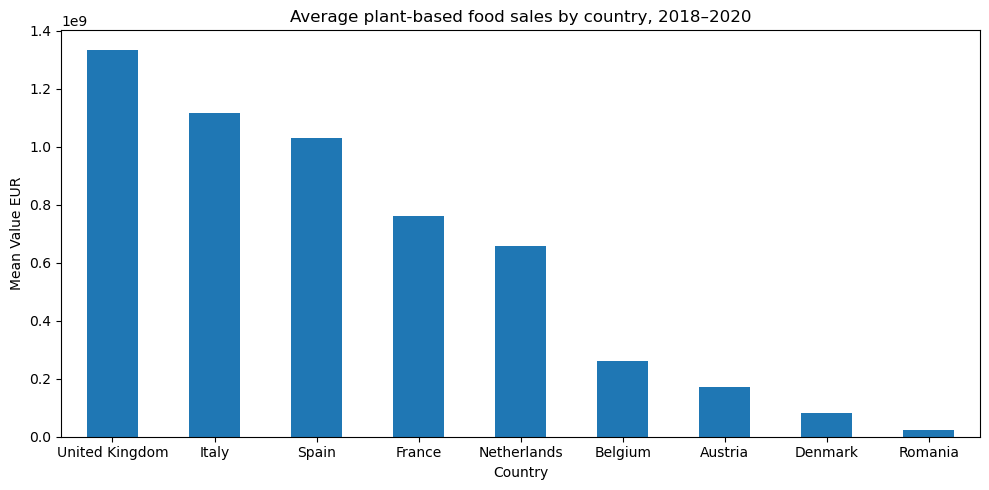

In [43]:
mean_value = country_descriptive[('Total Value EUR', 'mean')].sort_values(ascending=False)
mean_value.plot(kind='bar', figsize=(10, 5))
plt.title('Average plant-based food sales by country, 2018–2020')
plt.xlabel('Country')
plt.ylabel('Mean Value EUR')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The figure shows a clear concentration of plant-based food sales in a small number of markets from 2018 to 2020. The United Kingdom, Italy, and Spain accounted for the highest average sales values, suggesting that these countries had relatively larger and more developed plant-based food markets during this period. By contrast, countries such as Denmark and Romania showed much smaller sales values, indicating that market size differed substantially across Europe. This pattern suggests that plant-based food market development was uneven, with growth opportunities likely depending on country-specific market scale and consumer demand.


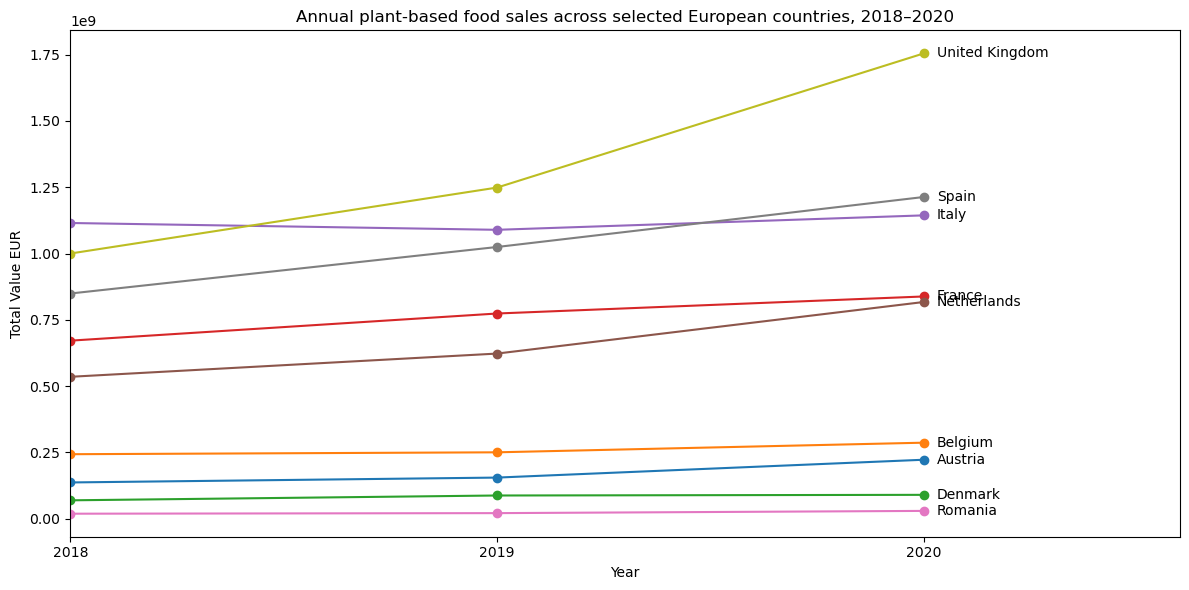

In [44]:
df_wide_value_wide = df_wide_value.pivot(
    index='Year',
    columns='Country',
    values='Total Value EUR')
ax = df_wide_value_wide.plot(
    figsize=(12, 6),
    marker='o',
    legend=False)
for country in df_wide_value_wide.columns:
    last_year = df_wide_value_wide.index[-1]
    last_value = df_wide_value_wide[country].iloc[-1]
    ax.text(last_year + 0.03, last_value, country, va='center')

plt.title('Annual plant-based food sales across selected European countries, 2018–2020')
plt.xlabel('Year')
plt.ylabel('Total Value EUR')
plt.xticks(df_wide_value_wide.index)
plt.xlim(df_wide_value_wide.index.min(), df_wide_value_wide.index.max() + 0.6)
plt.tight_layout()
plt.show()

Plant-based food sales increased in most selected European countries from 2018 to 2020, but the pace and scale of growth differed clearly across markets. The United Kingdom showed the strongest upward trend and became the leading market by 2020, while Spain and Italy remained consistently large markets. In contrast, countries such as Denmark and Romania stayed at much lower sales levels, suggesting that market expansion was uneven and mainly driven by a few major countries.


In [45]:
df_share, product_cols = create_share_table(df_wide_value)
df_share.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt,Total Value EUR
0,Austria,2018.0,NaN,NaN,NaN,34.989676,44.282113,20.728211,136487606.8
1,Austria,2019.0,NaN,NaN,NaN,34.521000,45.705517,19.773483,154842826.2
2,Austria,2020.0,NaN,NaN,NaN,38.906239,42.979341,18.114420,222198399.5
3,Belgium,2018.0,NaN,NaN,NaN,34.080908,47.870716,18.048376,243029408.0
4,Belgium,2019.0,NaN,NaN,NaN,34.879413,46.692554,18.428034,250165384.8


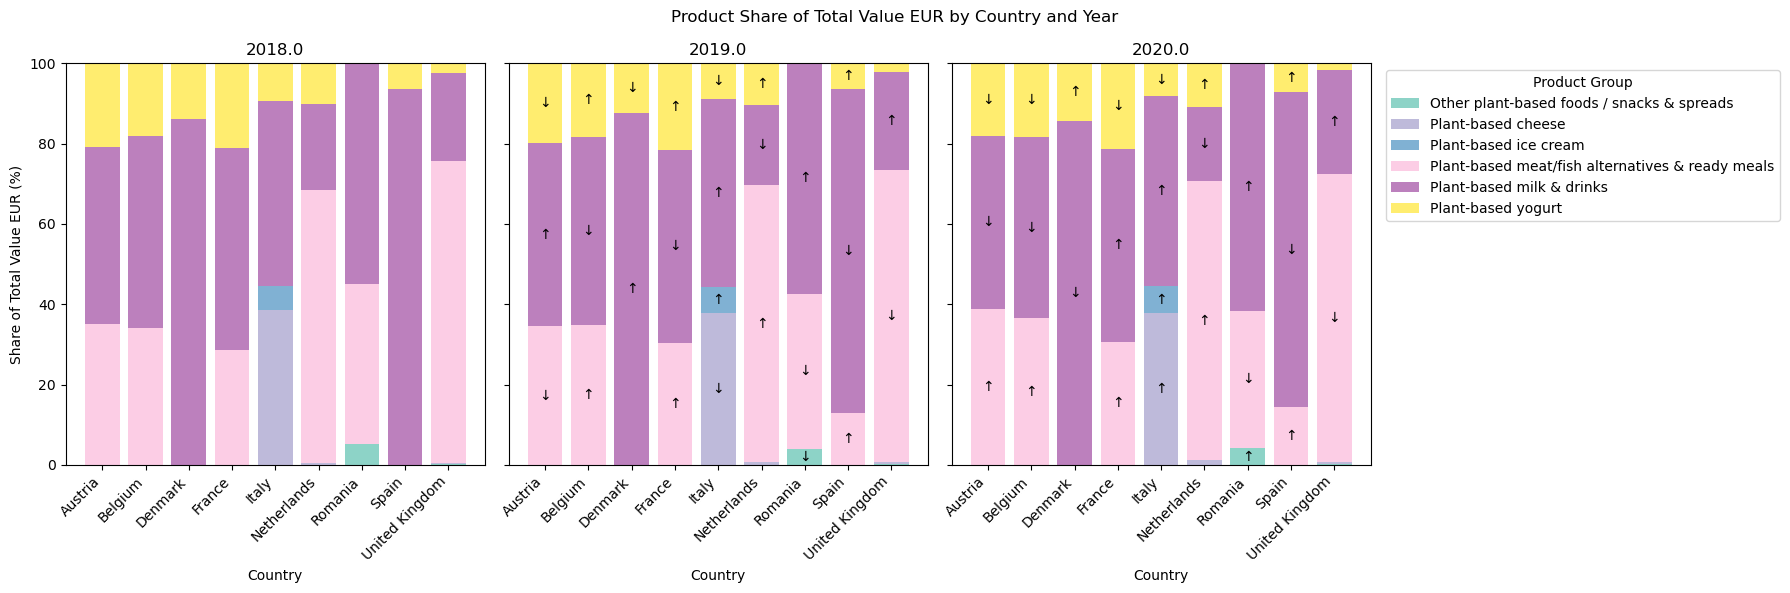

In [46]:
years = sorted(df_share['Year'].unique())
countries = sorted(df_share['Country'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(18, 6), sharey=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(product_cols)))
for i, year in enumerate(years):
    ax = axes[i]
    data = (df_share[df_share['Year'] == year].set_index('Country').reindex(countries)[product_cols].fillna(0))
    bottom = np.zeros(len(countries))
    for j, product in enumerate(product_cols):
        values = data[product].values
        ax.bar(countries,values,bottom=bottom,label=product,color=colors[j])
        if i > 0:
            prev_year = years[i - 1]
            prev_data = (df_share[df_share['Year'] == prev_year].set_index('Country').reindex(countries)[product_cols].fillna(0))
            change = data[product].values - prev_data[product].values
            for x, value, base, diff in zip(range(len(countries)), values, bottom, change):
                if value > 3:
                    if diff > 0:
                        ax.text(x, base + value / 2, '↑', ha='center', va='center')
                    elif diff < 0:
                        ax.text(x, base + value / 2, '↓', ha='center', va='center')
        bottom += values
    ax.set_title(str(year))
    ax.set_xlabel('Country')
    ax.set_xticks(range(len(countries)))
    ax.set_xticklabels(countries, rotation=45, ha='right')
    ax.set_ylim(0, 100)
axes[0].set_ylabel('Share of Total Value EUR (%)')

plt.suptitle('Product Share of Total Value EUR by Country and Year')
plt.legend(title='Product Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


The figure shows that the contribution of different product categories to total plant-based food sales varied substantially across countries and years. Plant-based milk and drinks accounted for a large share in many countries, especially in Denmark, Spain, Austria, Belgium, and France, indicating that this category was a key driver of total sales. In contrast, plant-based meat/fish alternatives and ready meals represented a particularly large share in the United Kingdom and the Netherlands, suggesting that these markets were more strongly shaped by meat-alternative products. The arrows show that category shares changed over time, but the overall market structure remained relatively stable in several countries. This suggests that plant-based food markets were not homogeneous across Europe; instead, each country appeared to have a different product-category profile, which may reflect differences in consumer preferences and market development pathways.


Cleaned YouTube Narrative Data

The following section no longer re-runs the YouTube API extraction or the old keyword dictionary. Instead, it directly uses the cleaned and aspect-coded CSV in `data/Clean`. The fourteen narrative columns are the seven requested dimensions split into positive and negative evaluations. Because the sales dataset covers 2018-2020, the YouTube data is filtered to the same period before the sales relationship analysis.


In [ ]:
youtube_path = Path("../data/Clean/ALL_11countries_2017_2020_aspect_sentiment.csv")
df_youtube_all = pd.read_csv(youtube_path, encoding="utf-8-sig")

aspects = [
    "health",
    "environment",
    "animal_welfare",
    "food_security",
    "taste",
    "price",
    "convenience",
]
narrative_cols = [f"{aspect}_{sentiment}" for aspect in aspects for sentiment in ["positive", "negative"]]

def format_narrative_label(column):
    aspect, sentiment = column.rsplit("_", 1)
    return f"{aspect.replace('_', ' ').title()} ({sentiment.title()})"

narrative_meta = pd.DataFrame({"narrative": narrative_cols})
narrative_meta["aspect"] = narrative_meta["narrative"].str.rsplit("_", n=1).str[0]
narrative_meta["sentiment"] = narrative_meta["narrative"].str.rsplit("_", n=1).str[1]
narrative_meta["label"] = narrative_meta["narrative"].apply(format_narrative_label)

df_youtube = df_youtube_all.copy()
df_youtube["Year"] = pd.to_numeric(df_youtube["year"], errors="coerce").astype("Int64")
df_youtube["Country"] = df_youtube["country"].astype(str).str.strip()
df_youtube[narrative_cols] = (
    df_youtube[narrative_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)
df_youtube["view_count_numeric"] = pd.to_numeric(df_youtube.get("view_count"), errors="coerce").fillna(0)

df_youtube_1820 = df_youtube[df_youtube["Year"].between(2018, 2020)].copy()

print("Loaded cleaned YouTube data from:", youtube_path)
print("All YouTube rows:", len(df_youtube_all))
print("YouTube rows used for 2018-2020 analysis:", len(df_youtube_1820))
print("Videos by year:")
print(df_youtube_1820["Year"].value_counts().sort_index())
print("Countries:", sorted(df_youtube_1820["Country"].dropna().unique()))
display(narrative_meta)
display(df_youtube_1820[["Country", "Year", "title"] + narrative_cols].head())


In [ ]:
example_rows = []
for narrative in narrative_cols:
    examples = (
        df_youtube_1820[df_youtube_1820[narrative].eq(1)]
        .sort_values("view_count_numeric", ascending=False)
        .head(3)
    )
    for _, row in examples.iterrows():
        example_rows.append({
            "narrative": format_narrative_label(narrative),
            "country": row["Country"],
            "year": int(row["Year"]),
            "title": row["title"],
            "url": row.get("url", ""),
            "view_count": int(row["view_count_numeric"]),
        })

example_videos = pd.DataFrame(example_rows)
display(example_videos)


The example table is used as a content check for the coded categories. It shows the actual video titles behind each narrative label, rather than only aggregate counts. The positive health, taste, and convenience categories are mostly recipe, diet, and practical-use videos, while negative and food-security categories are much rarer and therefore have fewer representative examples.


In [ ]:
narrative_by_year = df_youtube_1820.groupby("Year")[narrative_cols].sum()
narrative_rate_by_year = df_youtube_1820.groupby("Year")[narrative_cols].mean().mul(100)
narrative_totals = df_youtube_1820[narrative_cols].sum().sort_values(ascending=False)
narrative_rate_by_country = df_youtube_1820.groupby("Country")[narrative_cols].mean().mul(100)

display(narrative_totals.rename("mentioned_videos").to_frame())
display(narrative_by_year)


In [ ]:
plot_totals = narrative_totals.sort_values()
plot_labels = [format_narrative_label(col) for col in plot_totals.index]
plot_colors = ["#4C78A8" if col.endswith("_positive") else "#E45756" for col in plot_totals.index]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_labels, plot_totals.values, color=plot_colors)
ax.set_title("Total YouTube Videos Mentioning Each Narrative, 2018-2020")
ax.set_xlabel("Number of videos")
ax.set_ylabel("Narrative category")
for i, value in enumerate(plot_totals.values):
    ax.text(value + 5, i, f"{int(value)}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


Health-positive, taste-positive, and convenience-positive are the most frequently mentioned categories in the 2018-2020 YouTube data. Health-positive appears in 826 videos, taste-positive in 646, and convenience-positive in 548. Negative evaluations and food-security narratives are much less common, which suggests that the YouTube discussion is mainly framed around benefits, recipes, taste, and everyday usability rather than risks or scarcity.


In [ ]:
heatmap_year = narrative_rate_by_year[narrative_cols].T
heatmap_labels = [format_narrative_label(col) for col in heatmap_year.index]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(heatmap_year.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(heatmap_year.columns)))
ax.set_xticklabels(heatmap_year.columns.astype(int))
ax.set_yticks(range(len(heatmap_labels)))
ax.set_yticklabels(heatmap_labels)
ax.set_xlabel("Year")
ax.set_title("Narrative Mention Rate by Year (% of videos)")

for row_i in range(heatmap_year.shape[0]):
    for col_i in range(heatmap_year.shape[1]):
        value = heatmap_year.iloc[row_i, col_i]
        ax.text(col_i, row_i, f"{value:.1f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="% of videos")
plt.tight_layout()
plt.show()


The yearly heatmap shows that positive narratives dominate consistently across 2018-2020. Health-positive remains high in every year, around one quarter of all videos. Taste-positive peaks in 2019, while convenience-positive increases steadily and reaches about 20% of videos in 2020. Environmental-positive mentions become less frequent over time in this dataset, and negative categories remain small throughout.


In [ ]:
country_order = narrative_rate_by_country.mean(axis=1).sort_values(ascending=False).index
heatmap_country = narrative_rate_by_country.loc[country_order, narrative_cols]
country_labels = heatmap_country.index.tolist()
column_labels = [format_narrative_label(col) for col in heatmap_country.columns]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_country.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(column_labels)))
ax.set_xticklabels(column_labels, rotation=45, ha="right")
ax.set_yticks(range(len(country_labels)))
ax.set_yticklabels(country_labels)
ax.set_title("Narrative Mention Rate by Country, 2018-2020 (% of videos)")

for row_i in range(heatmap_country.shape[0]):
    for col_i in range(heatmap_country.shape[1]):
        value = heatmap_country.iloc[row_i, col_i]
        if value >= 10:
            ax.text(col_i, row_i, f"{value:.0f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="% of videos")
plt.tight_layout()
plt.show()


The country heatmap shows that the same broad pattern appears across many markets: health-positive, taste-positive, and convenience-positive are the most visible narratives, while negative categories are sparse. Belgium has the highest health-positive mention rate, the United Kingdom and Belgium are especially strong for taste-positive content, and Spain stands out for convenience-positive content. This suggests that country differences are mostly differences in emphasis rather than completely different narrative structures.


In [ ]:
sales_path = Path("../data/Clean/plant_based_food_sales_data.csv")
sales_raw_for_merge = pd.read_csv(sales_path)

sales_country_year = sales_raw_for_merge[["Country", "Year", "Value EUR"]].copy()
sales_country_year["Year"] = pd.to_numeric(sales_country_year["Year"], errors="coerce").astype("Int64")
sales_country_year["Value EUR"] = pd.to_numeric(sales_country_year["Value EUR"], errors="coerce").fillna(0)
sales_country_year = sales_country_year.dropna(subset=["Country", "Year"])
sales_country_year = sales_country_year[sales_country_year["Value EUR"] != 0]
sales_country_year = (
    sales_country_year
    .groupby(["Country", "Year"], as_index=False)["Value EUR"]
    .sum()
    .rename(columns={"Value EUR": "Total Value EUR"})
)
sales_country_year["Year"] = sales_country_year["Year"].astype(int)

narrative_country_year = (
    df_youtube_1820
    .groupby(["Country", "Year"])
    .agg(video_count=("video_id", "count"), **{col: (col, "sum") for col in narrative_cols})
    .reset_index()
)
narrative_country_year["Year"] = narrative_country_year["Year"].astype(int)
for col in narrative_cols:
    narrative_country_year[f"{col}_rate"] = narrative_country_year[col] / narrative_country_year["video_count"]

missing_sales_country_year = (
    narrative_country_year[["Country", "Year"]]
    .merge(sales_country_year[["Country", "Year"]], on=["Country", "Year"], how="left", indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

narrative_sales_country_year = narrative_country_year.merge(
    sales_country_year,
    on=["Country", "Year"],
    how="inner",
)
narrative_sales_country_year["log_total_value"] = np.log(narrative_sales_country_year["Total Value EUR"])

print("Country-year observations in YouTube data:", len(narrative_country_year))
print("Country-year observations used in sales relationship analysis:", len(narrative_sales_country_year))
print("Country-year observations without usable sales value:")
display(missing_sales_country_year)
display(narrative_sales_country_year.head())


For the sales relationship analysis, YouTube narratives are aggregated to the country-year level and merged with total sales value. This keeps the sales analysis aligned with the 2018-2020 period. The merge uses non-zero `Value EUR`; therefore Germany is listed as unmatched because the clean sales file does not contain usable non-zero sales value for Germany in these years. The YouTube-only narrative charts above still include Germany.


In [ ]:
rate_cols = [f"{col}_rate" for col in narrative_cols]

corr_table = pd.DataFrame({
    "narrative": narrative_cols,
    "corr_with_log_total_value": [
        narrative_sales_country_year[f"{col}_rate"].corr(narrative_sales_country_year["log_total_value"])
        for col in narrative_cols
    ],
})
corr_table = corr_table.merge(narrative_meta[["narrative", "label", "sentiment"]], on="narrative", how="left")
corr_table = corr_table.sort_values("corr_with_log_total_value", ascending=False)
display(corr_table[["label", "corr_with_log_total_value"]])

plot_corr = corr_table.sort_values("corr_with_log_total_value")
colors = ["#4C78A8" if value >= 0 else "#E45756" for value in plot_corr["corr_with_log_total_value"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_corr["label"], plot_corr["corr_with_log_total_value"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Correlation Between Narrative Mention Rate and Log Sales Value")
ax.set_xlabel("Correlation with log(Total Value EUR)")
ax.set_ylabel("Narrative category")
plt.tight_layout()
plt.show()


The correlation chart compares each narrative's country-year mention rate with log total plant-based food sales value. Taste-positive and price-positive show the strongest positive correlations, both around 0.44, followed by convenience-positive. Health-positive is positive but weaker. Taste-negative and food-security-positive are negatively correlated with sales value in this dataset. These are associations, not causal effects, but they suggest that consumer-facing benefits such as taste, affordability, and convenience are more closely aligned with larger sales markets than rare or problem-focused narratives.


In [ ]:
simple_relationships = []
for narrative in narrative_cols:
    rate_col = f"{narrative}_rate"
    x = narrative_sales_country_year[rate_col].astype(float)
    y = narrative_sales_country_year["log_total_value"].astype(float)
    if x.nunique() > 1:
        slope, intercept = np.polyfit(x, y, 1)
        y_hat = slope * x + intercept
        ss_res = ((y - y_hat) ** 2).sum()
        ss_tot = ((y - y.mean()) ** 2).sum()
        r_squared = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    else:
        slope = np.nan
        r_squared = np.nan
    simple_relationships.append({
        "narrative": narrative,
        "label": format_narrative_label(narrative),
        "slope_per_10pp_rate_increase": slope * 0.10,
        "r_squared": r_squared,
    })

simple_relationships = (
    pd.DataFrame(simple_relationships)
    .sort_values("r_squared", ascending=False)
    .reset_index(drop=True)
)
display(simple_relationships)

top_scatter = corr_table.assign(abs_corr=corr_table["corr_with_log_total_value"].abs()).head(0)
top_scatter = corr_table.assign(abs_corr=corr_table["corr_with_log_total_value"].abs()).sort_values("abs_corr", ascending=False).head(4)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for ax, (_, row) in zip(axes, top_scatter.iterrows()):
    narrative = row["narrative"]
    rate_col = f"{narrative}_rate"
    x = narrative_sales_country_year[rate_col] * 100
    y = narrative_sales_country_year["log_total_value"]
    ax.scatter(x, y, alpha=0.75)
    if x.nunique() > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color="red")
    ax.set_title(row["label"])
    ax.set_xlabel("Mention rate (% of videos)")
    ax.set_ylabel("Log Total Value EUR")
plt.tight_layout()
plt.show()


The bivariate slope table and scatter plots give a more direct view of the strongest simple relationships. Taste-positive and price-positive have the highest simple explanatory power, but their R-squared values remain below 0.20. This means narrative mention rates are related to sales value, but they explain only part of the difference across countries and years. Market size, product availability, retail structure, and country-level demand are still important background factors.


In [ ]:
rate_corr = narrative_sales_country_year[rate_cols].corr()
rate_corr.index = [format_narrative_label(col.replace("_rate", "")) for col in rate_corr.index]
rate_corr.columns = [format_narrative_label(col.replace("_rate", "")) for col in rate_corr.columns]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(rate_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(rate_corr.columns)))
ax.set_xticklabels(rate_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(rate_corr.index)))
ax.set_yticklabels(rate_corr.index)
ax.set_title("Correlation Among Narrative Mention Rates")

for row_i in range(rate_corr.shape[0]):
    for col_i in range(rate_corr.shape[1]):
        value = rate_corr.iloc[row_i, col_i]
        if abs(value) >= 0.5 or row_i == col_i:
            ax.text(col_i, row_i, f"{value:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


The narrative-correlation heatmap shows that the fourteen categories are not fully independent. Some positive consumer-facing narratives tend to appear in the same country-year contexts, and several rare negative categories are sparse. This matters for interpretation: a strong correlation with sales may reflect a broader communication environment rather than the isolated effect of one narrative. For this reason, the notebook emphasizes descriptive patterns and simple associations instead of treating the fourteen narrative variables as independent causal predictors.
